<a href="https://colab.research.google.com/github/turayusa/homework/blob/main/1_2_Activity_Week_1_Jupyter_Notebook_%E2%80%93_Linear_Regression_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DX799 Data Science Capstone

## Week 1 Jupyter Notebook – Linear Regression

### Diabetes Hospitalization Analysis with Linear Regression, Polynomial Terms, and Interaction Effects

**Student:** Abdul Karim Turay  
**Course:** DX799 Data Science Capstone  
**Semester:** Fall 2026  
**Week:** Week 1 – Linear Regression  
**Dataset:** Diabetes Hospitalization Dataset  

---

### Project Objective

The objective of this analysis is to investigate factors associated with hospital length of stay (`time_in_hospital`) among patients with diabetes. Linear regression techniques are used to examine continuous and categorical predictors, polynomial relationships, interaction effects, and multicollinearity.

Model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²).

# Table of Contents

1. Data Preparation and Linear Regression Review
2. Linear Regression: Baseline Model
3. Polynomial Regression
   - 3A. Polynomial Regression: Squared Terms Only
   - 3B. Interaction Terms Only
   - 3C. Regression Model Comparison
4. Residual Analysis
5. Actual vs. Predicted Values
6. Multicollinearity Assessment
   - 6A. Correlation Analysis
   - 6B. Variance Inflation Factor (VIF)
7. Continuous and Categorical Features
8. Optimal Modeling Strategy
9. Final Model Comparison and Conclusion

# Week 1 Python Notebook - Linear Regression 1

## Diabetes Hospitalization Analysis

### Objective

The objective of this Week 1 analysis is to examine factors associated with time in hospital among patients with diabetes using linear regression.

I will first build a baseline linear regression model using continuous predictors. I will then examine polynomial terms and interaction effects to identify possible nonlinear relationships and interactions between predictors. Correlation and variance inflation factor (VIF) will be used to assess multicollinearity. Finally, categorical patient characteristics will be incorporated and the regression models will be compared to identify an appropriate modeling strategy.

## 1. Data Preparation and Linear Regression Review

Before completing the Week 1 regression analysis, the dataset is loaded and reviewed to confirm its structure, number of observations, variables, and data types.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

# Upload dataset directly
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Confirm dataset
print("File loaded:", filename)
print("Dataset shape:", df.shape)

# Display first five observations
df.head()

Saving diabetic_data.csv to diabetic_data.csv
File loaded: diabetic_data.csv
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Data Cleaning and Variable Selection

Missing values denoted by "?" are replaced with NaN. Variables relevant to the Week 1 linear regression analysis are selected, with `time_in_hospital` serving as the continuous outcome variable.

In [3]:
# Convert "?" values to missing values
df = df.replace("?", np.nan)

# Select variables for the Week 1 analysis
variables = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'age',
    'gender',
    'race'
]

df_analysis = df[variables].copy()

# Examine missing values
print("Dataset shape before cleaning:", df_analysis.shape)
print("\nMissing values:")
print(df_analysis.isnull().sum())

Dataset shape before cleaning: (101766, 11)

Missing values:
time_in_hospital         0
num_lab_procedures       0
num_procedures           0
num_medications          0
number_outpatient        0
number_emergency         0
number_inpatient         0
number_diagnoses         0
age                      0
gender                   0
race                  2273
dtype: int64


### Handling Missing Data

Among the selected variables, only `race` has missing values, with 2,273 observations missing. Because this represents a small proportion of the dataset, complete-case analysis is used by removing observations with missing values before regression modeling.

In [4]:
# Remove observations with missing values
df_clean = df_analysis.dropna().copy()

# Compare dataset size before and after cleaning
original_rows = len(df_analysis)
clean_rows = len(df_clean)
removed_rows = original_rows - clean_rows

print("Original observations:", original_rows)
print("Observations after cleaning:", clean_rows)
print("Observations removed:", removed_rows)
print("Percentage retained:", round((clean_rows / original_rows) * 100, 2), "%")
print("Percentage removed:", round((removed_rows / original_rows) * 100, 2), "%")

Original observations: 101766
Observations after cleaning: 99493
Observations removed: 2273
Percentage retained: 97.77 %
Percentage removed: 2.23 %


### Analysis

The dataset had 101,766 observations before cleaning. I found 2,273 missing values in `race`, so I removed those rows using complete-case analysis. After cleaning, 99,493 observations remained.

Overall, 97.77% of the data was retained and 2.23% was removed. Since only a small portion of the data was lost, I used the remaining observations for the regression analysis.

## 2. Linear Regression: Baseline Model

### Objective

The objective of this analysis is to develop a baseline multiple linear regression model to examine the relationship between patient characteristics and `time_in_hospital`.

The baseline model serves as a benchmark for determining whether more complex models, such as polynomial and interaction models, improve predictive performance.

In [5]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define numeric predictors
features = [
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Define predictor matrix and outcome variable
X = df_clean[features]
y = df_clean['time_in_hospital']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display dimensions
print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

# Fit baseline multiple linear regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Make predictions
y_pred = baseline_model.predict(X_test)

# Calculate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nBaseline Linear Regression Performance")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R-squared:", round(r2, 3))

Training observations: 79594
Testing observations: 19899

Baseline Linear Regression Performance
MAE: 1.936
RMSE: 2.541
R-squared: 0.271


### Analysis

The dataset was split into 79,594 training observations and 19,899 testing observations using an 80/20 train-test split.

The baseline multiple linear regression model produced an MAE of 1.936 days and an RMSE of 2.541 days. The MAE shows that the predictions differed from the actual hospital stay by about 1.94 days on average. The higher RMSE indicates that some predictions had larger errors.

The R-squared value was 0.271, meaning that the model explained about 27.1% of the variation in `time_in_hospital`. The numeric predictors provide some predictive information, but much of the variation in hospital stay remains unexplained. These results provide a baseline for comparison with the polynomial and interaction models.

#### Regression Coefficients

The regression coefficients are examined to understand the direction and magnitude of the relationship between each predictor and `time_in_hospital`, while holding the other predictors constant.

In [6]:
# Create a table of regression coefficients
coefficient_table = pd.DataFrame({
    'Predictor': features,
    'Coefficient': baseline_model.coef_
})

# Sort coefficients from largest to smallest
coefficient_table = coefficient_table.sort_values(
    by='Coefficient',
    ascending=False
).reset_index(drop=True)

# Display model intercept
print("Intercept:", round(baseline_model.intercept_, 3))

# Display coefficient table
coefficient_table

Intercept: -0.26


,Predictor,Coefficient
0,number_diagnoses,0.140819
1,num_medications,0.138579
2,number_inpatient,0.103360
3,num_procedures,0.052869
4,num_lab_procedures,0.030274
5,number_outpatient,-0.079352
6,number_emergency,-0.091241


### Analysis

The regression coefficients show how each predictor is associated with `time_in_hospital` while holding the other predictors constant.

Positive coefficients indicate longer predicted hospital stays as the predictor increases. Negative coefficients indicate shorter predicted hospital stays.

Among the predictors, larger positive coefficients suggest stronger positive associations with hospital stay, while negative coefficients suggest inverse associations.

The intercept represents the predicted value of `time_in_hospital` when all numeric predictors are zero. Since this may not represent a realistic patient, the intercept has limited practical meaning.

These coefficients describe associations within the regression model and should not be interpreted as causal effects.

## 3. Polynomial Regression

### Objective

The objective of this analysis is to determine whether nonlinear relationships between the numeric predictors and `time_in_hospital` improve predictive performance compared with the baseline multiple linear regression model.

A second-degree polynomial model is used to include squared terms while retaining the original predictors. MAE, RMSE, and R-squared are used to evaluate the model and compare its performance with the baseline model.

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create second-degree polynomial features
# interaction_only=False includes squared terms and interactions
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

# Transform training and testing data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Make predictions
y_pred_poly = poly_model.predict(X_test_poly)

# Calculate performance metrics
poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
poly_r2 = r2_score(y_test, y_pred_poly)

# Display results
print("Original number of predictors:", X_train.shape[1])
print("Number of polynomial features:", X_train_poly.shape[1])

print("\nPolynomial Regression Performance")
print("MAE:", round(poly_mae, 3))
print("RMSE:", round(poly_rmse, 3))
print("R-squared:", round(poly_r2, 3))

print("\nBaseline Regression Performance")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R-squared:", round(r2, 3))

Original number of predictors: 7
Number of polynomial features: 35

Polynomial Regression Performance
MAE: 1.888
RMSE: 2.491
R-squared: 0.299

Baseline Regression Performance
MAE: 1.936
RMSE: 2.541
R-squared: 0.271


### Analysis

The second-degree polynomial model expanded the 7 original predictors to 35 features by adding squared terms and pairwise interaction terms.

The polynomial model produced an MAE of 1.888 days and an RMSE of 2.491 days. The baseline model had an MAE of 1.936 days and an RMSE of 2.541 days. The lower error values show a small improvement in prediction accuracy.

R-squared also increased from 0.271 to 0.299. This means that the polynomial model explained about 29.9% of the variation in `time_in_hospital`, compared with 27.1% for the baseline model.

Overall, the polynomial model performed slightly better than the baseline model. However, about 70.1% of the variation in hospital stay remains unexplained, suggesting that other factors may also contribute to length of stay.

### 3A. Polynomial Regression: Squared Terms Only

#### Objective

This analysis tests whether adding squared terms for the seven numeric predictors improves the prediction of `time_in_hospital` compared with the baseline linear regression model.

The squared terms are used to capture possible nonlinear relationships between each predictor and hospital length of stay. Interaction terms are not included in this model.

In [8]:
# Create squared terms only
X_train_squared = X_train.copy()
X_test_squared = X_test.copy()

# Add squared term for each predictor
for feature in features:
    X_train_squared[feature + '_squared'] = X_train[feature] ** 2
    X_test_squared[feature + '_squared'] = X_test[feature] ** 2

# Fit squared-terms regression model
squared_model = LinearRegression()
squared_model.fit(X_train_squared, y_train)

# Make predictions
y_pred_squared = squared_model.predict(X_test_squared)

# Calculate performance metrics
squared_mae = mean_absolute_error(y_test, y_pred_squared)
squared_rmse = np.sqrt(mean_squared_error(y_test, y_pred_squared))
squared_r2 = r2_score(y_test, y_pred_squared)

# Display results
print("Original number of predictors:", X_train.shape[1])
print("Number of features with squared terms:", X_train_squared.shape[1])

print("\nSquared-Term Regression Performance")
print("MAE:", round(squared_mae, 3))
print("RMSE:", round(squared_rmse, 3))
print("R-squared:", round(squared_r2, 3))

print("\nBaseline Regression Performance")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R-squared:", round(r2, 3))

Original number of predictors: 7
Number of features with squared terms: 14

Squared-Term Regression Performance
MAE: 1.914
RMSE: 2.516
R-squared: 0.285

Baseline Regression Performance
MAE: 1.936
RMSE: 2.541
R-squared: 0.271


#### Analysis

The squared-terms model increased the number of features from 7 to 14 by adding one squared term for each numeric predictor.

The model produced an MAE of 1.914 days and an RMSE of 2.516 days, compared with 1.936 and 2.541 days for the baseline model. The lower values show a small reduction in prediction error.

R-squared increased from 0.271 to 0.285. This means that the squared-terms model explained about 28.5% of the variation in `time_in_hospital`, compared with 27.1% for the baseline model.

Overall, adding squared terms slightly improved model performance. This suggests that some predictors may have nonlinear relationships with hospital length of stay, although much of the variation remains unexplained.

### 3B. Interaction Terms Only

#### Objective

This analysis tests whether adding interaction terms between the seven numeric predictors improves the prediction of `time_in_hospital` compared with the baseline linear regression model.

Interaction terms are used to capture whether the relationship between one predictor and hospital length of stay changes depending on another predictor. Squared terms are not included, so the interaction effects can be examined separately.

In [9]:
# 3B. Interaction Terms Only

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create interaction terms only
interaction = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

# Transform training and testing data
X_train_interaction = interaction.fit_transform(X_train)
X_test_interaction = interaction.transform(X_test)

# Train interaction-only regression model
interaction_model = LinearRegression()
interaction_model.fit(X_train_interaction, y_train)

# Make predictions
y_pred_interaction = interaction_model.predict(X_test_interaction)

# Calculate performance metrics
interaction_mae = mean_absolute_error(y_test, y_pred_interaction)
interaction_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_interaction)
)
interaction_r2 = r2_score(y_test, y_pred_interaction)

# Display number of features
print("Original number of predictors:", X_train.shape[1])
print("Number of features with interactions:",
      X_train_interaction.shape[1])

# Display interaction model performance
print("\nInteraction-Only Regression Performance")
print("MAE:", round(interaction_mae, 3))
print("RMSE:", round(interaction_rmse, 3))
print("R-squared:", round(interaction_r2, 3))

# Display baseline performance for comparison
print("\nBaseline Regression Performance")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R-squared:", round(r2, 3))

Original number of predictors: 7
Number of features with interactions: 28

Interaction-Only Regression Performance
MAE: 1.902
RMSE: 2.509
R-squared: 0.289

Baseline Regression Performance
MAE: 1.936
RMSE: 2.541
R-squared: 0.271


#### Analysis

The interaction-only regression model increased the number of features from 7 to 28 by including pairwise interaction terms between the seven numeric predictors.

The model produced an MAE of 1.902 days and an RMSE of 2.509 days, compared with 1.936 and 2.541 days for the baseline model. The lower MAE and RMSE show a small reduction in prediction error.

R-squared increased from 0.271 for the baseline model to 0.289 for the interaction-only model. This means that the interaction model explained about 28.9% of the variation in `time_in_hospital`, compared with 27.1% for the baseline model.

Overall, adding interaction terms slightly improved model performance. The interaction-only model also performed slightly better than the squared-terms-only model, which had an R-squared value of 0.285. This suggests that relationships between pairs of predictors may provide additional information for predicting hospital length of stay.

### 3C. Regression Model Comparison

#### Objective

The objective of this analysis is to compare the predictive performance of the baseline linear regression, squared-terms, interaction-only, and full polynomial regression models.

The models are compared using MAE, RMSE, and R-squared to evaluate how nonlinear and interaction effects influence the prediction of `time_in_hospital`.

In [10]:
# Compare performance of all regression models

comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Squared Terms Only",
        "Interaction Terms Only",
        "Full Polynomial Regression"
    ],
    "MAE": [
        mae,
        squared_mae,
        interaction_mae,
        poly_mae
    ],
    "RMSE": [
        rmse,
        squared_rmse,
        interaction_rmse,
        poly_rmse
    ],
    "R-squared": [
        r2,
        squared_r2,
        interaction_r2,
        poly_r2
    ]
})

# Round results for easier interpretation
comparison[["MAE", "RMSE", "R-squared"]] = (
    comparison[["MAE", "RMSE", "R-squared"]].round(3)
)

comparison

,Model,MAE,RMSE,R-squared
0,Baseline Linear Regression,1.936,2.541,0.271
1,Squared Terms Only,1.914,2.516,0.285
2,Interaction Terms Only,1.902,2.509,0.289
3,Full Polynomial Regression,1.888,2.491,0.299


#### Analysis

The four regression models were evaluated using MAE, RMSE, and R-squared. The baseline linear regression model had an MAE of 1.936 days, an RMSE of 2.541 days, and an R-squared value of 0.271.

Adding squared terms slightly improved performance by lowering the MAE to 1.914 days and the RMSE to 2.516 days, while increasing R-squared to 0.285. The interaction-only model showed a further improvement, with an MAE of 1.902 days, an RMSE of 2.509 days, and an R-squared of 0.289.

The full polynomial regression model, which included both squared and interaction terms, had the lowest prediction errors, with an MAE of 1.888 days and an RMSE of 2.491 days. It also had the highest R-squared value of 0.299, explaining about 29.9% of the variation in `time_in_hospital`.

Overall, model performance improved as squared and interaction terms were added. The results suggest that these terms provide additional predictive information beyond the baseline linear relationships. However, the improvements were modest, and much of the variation in hospital length of stay remains unexplained.

## 4. Residual Analysis

### Objective

The objective of this analysis is to examine the prediction errors from the full polynomial regression model.

Residuals are the differences between the actual and predicted values of `time_in_hospital`. Examining their distribution helps determine whether the prediction errors are centered around zero and whether any patterns suggest limitations in the regression model.

Residual Summary
Mean residual: -0.027
Standard deviation: 2.491
Minimum residual: -8.694
Maximum residual: 12.27


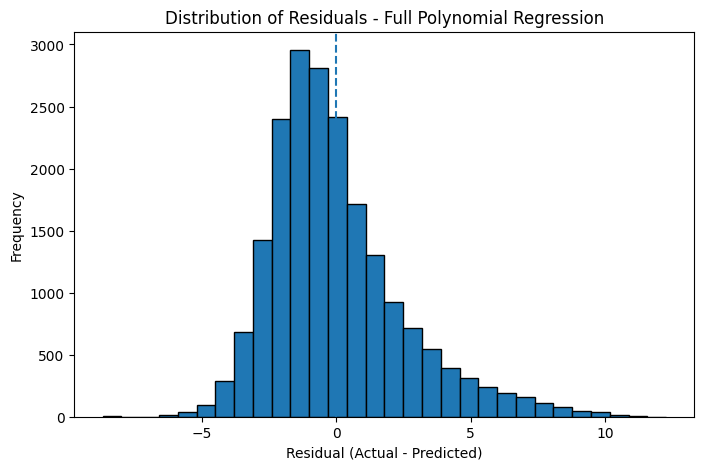

In [11]:
# Calculate residuals for the full polynomial regression model
residuals = y_test - y_pred_poly

# Display residual summary statistics
print("Residual Summary")
print("Mean residual:", round(residuals.mean(), 3))
print("Standard deviation:", round(residuals.std(), 3))
print("Minimum residual:", round(residuals.min(), 3))
print("Maximum residual:", round(residuals.max(), 3))

# Plot residual distribution
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor="black")

plt.axvline(0, linestyle="--")

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals - Full Polynomial Regression")

plt.show()
plt.close()

### Analysis

The residuals from the full polynomial regression model had a mean of -0.027 days, which is very close to zero. This means that, on average, the model does not demonstrate significant overprediction or underprediction of 'time_in_hospital'.

The residual standard deviation was 2.491 days, demonstrating that prediction errors varied by several days around the estimated hospital stay. Residuals varied from -8.694 to 12.270 days, indicating that some individual observations had significant forecast errors.

The histogram shows that most residuals are concentrated near zero, although the distribution is not perfectly symmetric and has a longer right tail. Positive residuals reflect cases in which the actual hospital stay was longer than expected. As a result, the right tail indicates that the model significantly underestimated the hospital length of stay for some individuals.

Overall, the residual analysis shows that the model's prediction errors are roughly centered around zero, but the right-skewed distribution and somewhat large residuals imply that the full polynomial regression model does not account for all characteristics associated with longer hospital stays.

## 5. Actual vs. Predicted Values

### Objective

The objective of this study is to compare the actual values of `time_in_hospital` to the values predicted by the full polynomial regression model.

The actual-versus-predicted plot assesses how well the model's predictions correspond to the observed values of `time_in_hospital`. The diagonal reference line corresponds to perfect predictions.

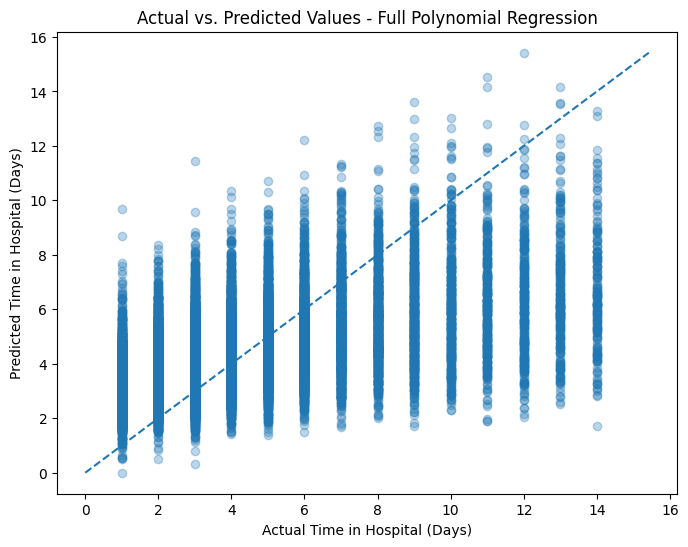

In [12]:
# Actual vs. Predicted Values for Full Polynomial Regression

plt.figure(figsize=(8, 6))

# Plot actual versus predicted values
plt.scatter(
    y_test,
    y_pred_poly,
    alpha=0.3
)

# Create reference line for perfect predictions
min_value = min(y_test.min(), y_pred_poly.min())
max_value = max(y_test.max(), y_pred_poly.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

# Add labels and title
plt.xlabel("Actual Time in Hospital (Days)")
plt.ylabel("Predicted Time in Hospital (Days)")
plt.title("Actual vs. Predicted Values - Full Polynomial Regression")

plt.show()
plt.close()

### Analysis

The actual-versus-predicted plot reveals a positive relationship between observed and predicted hospital lengths of stay. As actual `time_in_hospital` increases, the model generally predicts longer hospital stays.

However, the predicted values are widely distributed around the diagonal reference line, showing that the model does not accurately predict every individual hospital stay. For shorter actual stays, some predictions are above the reference line, indicating overprediction. For longer actual stays, many predictions fall below the reference line, indicating underprediction.

The vertical bands appear because the actual `time_in_hospital` variable has discrete whole-day values ranging from 1 to 14 days, while the regression model produces continuous predicted values.

Overall, the plot is consistent with the model's R-squared value of 0.299. The full polynomial regression model explains some of the variation in hospital length of stay, but much of the variation remains unexplained.

## 6. Multicollinearity Assessment

### Objective

The objective of this analysis is to determine the multicollinearity among the continuous predictor variables utilized in the regression models.

Multicollinearity occurs when predictor variables are strongly correlated with one another, making regression coefficients unstable and difficult to interpret. To assess multicollinearity, correlation analysis and the Variance Inflation Factor (VIF) are utilized.

### 6A. Correlation Analysis

A correlation matrix examines the strength and direction of linear correlations among continuous predictors.

In [13]:
# Calculate correlation matrix for the continuous predictors
correlation_matrix = df_clean[features].corr()

# Display correlation matrix
print("Correlation Matrix")
display(correlation_matrix.round(3))

Correlation Matrix


,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
num_lab_procedures,1.000,0.058,0.267,-0.009,-0.002,0.040,0.152
num_procedures,0.058,1.000,0.386,-0.025,-0.038,-0.066,0.072
num_medications,0.267,0.386,1.000,0.045,0.013,0.065,0.259
number_outpatient,-0.009,-0.025,0.045,1.000,0.091,0.106,0.092
number_emergency,-0.002,-0.038,0.013,0.091,1.000,0.266,0.054
number_inpatient,0.040,-0.066,0.065,0.106,0.266,1.000,0.103
number_diagnoses,0.152,0.072,0.259,0.092,0.054,0.103,1.000


### Analysis

The correlation matrix indicates that the continuous predictors have weak to moderate correlations with one another.

The strongest correlation found was between `num_procedures` and `num_medications` (r = 0.386), indicating a moderate positive correlation. `num_lab_procedures` and `num_medications` also had a positive correlation (r = 0.267).

The majority of the remaining correlations were relatively weak. There were no strong pairwise correlations among the continuous predictors, indicating that severe multicollinearity is unlikely based on correlation analysis alone.

However, correlation analysis only assesses pairwise relationships. As a result, the Variance Inflation Factor (VIF) will be calculated to further assess multicollinearity among the predictors.

### 6B. Variance Inflation Factor (VIF)

The Variance Inflation Factor (VIF) is used to determine how much the variance of a regression coefficient is inflated due to correlations with other predictor variables. Higher VIF values suggest increased multicollinearity.

In [14]:
# Import VIF function
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare continuous predictors for VIF analysis
X_vif = df_clean[features].astype(float)

# Add constant
X_vif = add_constant(X_vif)

# Calculate VIF for each predictor
vif_results = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Remove constant from displayed results
vif_results = vif_results[
    vif_results["Predictor"] != "const"
].reset_index(drop=True)

# Display VIF results
print("Variance Inflation Factor (VIF)")
display(vif_results.round(3))

Variance Inflation Factor (VIF)


,Predictor,VIF
0,num_lab_procedures,1.089
1,num_procedures,1.191
2,num_medications,1.337
3,number_outpatient,1.025
4,number_emergency,1.082
5,number_inpatient,1.102
6,number_diagnoses,1.096


### Analysis

All seven continuous predictors had low VIF values (1.025–1.337), with `num_medications` having the highest at 1.337 and `num_procedures` at 1.191. All remaining predictors had VIF values close to one.

These values are well below the typically used thresholds for detecting serious multicollinearity. As a result, the VIF analysis shows that multicollinearity is not a major concern for the continuous predictors.

This finding is consistent with the correlation analysis, which revealed no strong correlations between the predictors. According to these findings, there is no need to remove any of the continuous predictors due to multicollinearity.

## 7. Continuous and Categorical Features

### Objective

The objective of this analysis is to see if including categorical patient variables improves the prediction of `time_in_hospital`.

The previous regression models had seven continuous predictors. In this analysis, `age`, `gender`, and `race` are included as categorical predictors. Dummy variables are created to accommodate these categorical features in the linear regression model.

The continuous-and-categorical model's performance will be compared to the baseline linear regression model using MAE, RMSE, and R-squared.

In [15]:
# Define continuous and categorical predictors
continuous_features = features
categorical_features = ['age', 'gender', 'race']

# Create predictor dataset
X_mixed = df_clean[
    continuous_features + categorical_features
].copy()

# Convert categorical variables to dummy variables
X_mixed_encoded = pd.get_dummies(
    X_mixed,
    columns=categorical_features,
    drop_first=True,
    dtype=float
)

# Define outcome
y_mixed = df_clean['time_in_hospital']

# Split data using the same 80/20 split and random state
X_train_mixed, X_test_mixed, y_train_mixed, y_test_mixed = train_test_split(
    X_mixed_encoded,
    y_mixed,
    test_size=0.20,
    random_state=42
)

# Fit linear regression model
mixed_model = LinearRegression()
mixed_model.fit(X_train_mixed, y_train_mixed)

# Make predictions
y_pred_mixed = mixed_model.predict(X_test_mixed)

# Calculate performance metrics
mixed_mae = mean_absolute_error(y_test_mixed, y_pred_mixed)
mixed_rmse = np.sqrt(
    mean_squared_error(y_test_mixed, y_pred_mixed)
)
mixed_r2 = r2_score(y_test_mixed, y_pred_mixed)

# Display model information
print("Continuous predictors:", len(continuous_features))
print("Categorical predictors:", len(categorical_features))
print("Total encoded features:", X_mixed_encoded.shape[1])

print("\nContinuous + Categorical Model Performance")
print("MAE:", round(mixed_mae, 3))
print("RMSE:", round(mixed_rmse, 3))
print("R-squared:", round(mixed_r2, 3))

print("\nBaseline Regression Performance")
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R-squared:", round(r2, 3))

Continuous predictors: 7
Categorical predictors: 3
Total encoded features: 22

Continuous + Categorical Model Performance
MAE: 1.919
RMSE: 2.52
R-squared: 0.282

Baseline Regression Performance
MAE: 1.936
RMSE: 2.541
R-squared: 0.271


### Analysis

The model had seven continuous predictors and three categorical predictors (`age`, `gender`, and `race`). After dummy encoding the categorical variables, the model had 22 features.

The model had an MAE of 1.919 days and an RMSE of 2.520 days, compared to 1.936 days and 2.541 days for the baseline model. Both prediction errors decreased slightly after the categorical predictors were added.

The R-squared value increased from 0.271 for the baseline model to 0.282 for the continuous-and-categorical model. This means that the model explained around 28.2% of the variation in `time_in_hospital`, compared to 27.1% for the baseline model.

Overall, adding age, gender, and race resulted in a small improvement in prediction performance. This suggests that categorical patient features provided some additional information for predicting hospital length of stay, although the improvement was small.

## 8. Optimal Modeling Strategy

### Objective

The objective of this analysis is to identify a suitable modeling approach for predicting `time_in_hospital` based on the results of the regression models assessed in Week 1.

The baseline model, squared-terms model, interaction-only model, full polynomial model, and continuous-and-categorical model are collectively evaluated. Model performance is assessed using MAE, RMSE, and R-squared, alongside an examination of the multicollinearity results.

In [16]:
# Compare all Week 1 regression models

strategy_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Squared Terms Only",
        "Interaction Terms Only",
        "Full Polynomial Regression",
        "Continuous + Categorical"
    ],
    "MAE": [
        mae,
        squared_mae,
        interaction_mae,
        poly_mae,
        mixed_mae
    ],
    "RMSE": [
        rmse,
        squared_rmse,
        interaction_rmse,
        poly_rmse,
        mixed_rmse
    ],
    "R-squared": [
        r2,
        squared_r2,
        interaction_r2,
        poly_r2,
        mixed_r2
    ]
})

# Round values for easier interpretation
strategy_comparison[
    ["MAE", "RMSE", "R-squared"]
] = strategy_comparison[
    ["MAE", "RMSE", "R-squared"]
].round(3)

# Display comparison table
strategy_comparison

,Model,MAE,RMSE,R-squared
0,Baseline Linear Regression,1.936,2.541,0.271
1,Squared Terms Only,1.914,2.516,0.285
2,Interaction Terms Only,1.902,2.509,0.289
3,Full Polynomial Regression,1.888,2.491,0.299
4,Continuous + Categorical,1.919,2.520,0.282


### Analysis

The five regression models showed modest differences in predictive performance.

The baseline linear regression model had an MAE of 1.936 days, an RMSE of 2.541 days, and an R-squared value of 0.271. Incorporating categorical variables increased the R-squared value to 0.282, whereas the models utilizing squared terms and interactions increased R-squared to 0.285 and 0.289, respectively.

The full polynomial regression model yielded the lowest MAE (1.888 days), the lowest RMSE (2.491 days), and the highest R-squared value (0.299) compared to the evaluated models. This suggests that the incorporation of both squared and interaction terms captured additional relationships not represented in the baseline linear model.

The multicollinearity assessment revealed low VIF values for the continuous predictors, suggesting that multicollinearity was not a major issue.

According to the models assessed in this analysis, the full polynomial regression model had the strongest predictive performance. Nonetheless, the improvement compared to the baseline model was slight, and about 70% of the variation in `time_in_hospital` remained unexplained.

Consequently, the findings indicate that nonlinear and interaction effects are useful for this dataset, while additional patient or clinical features may be required to improve prediction.

## 9. Final Model Comparison and Conclusion

Five regression models were tested to predict `time_in_hospital` in diabetic patients.

The baseline linear regression model yielded an MAE of 1.936 days, an RMSE of 2.541 days, and an R-squared of 0.271. Including categorical patient features (`age`, `gender`, and `race`) slightly improved performance, yielding an MAE of 1.919 days, an RMSE of 2.520 days, and an R-squared value of 0.282.

Adding squared terms to the continuous predictors improved performance further, with an MAE of 1.914 days, an RMSE of 2.516 days, and an R-squared value of 0.285. The interaction-only model yielded an MAE of 1.902 days, an RMSE of 2.509 days, and an R-squared of 0.289.

The full polynomial regression model had the lowest MAE (1.888 days), lowest RMSE (2.491 days), and highest R-squared value (0.299). This shows that integrating both squared and interaction terms captured additional nonlinear relationships and interaction effects among the continuous predictors.

The correlation and VIF analyses did not reveal strong evidence of multicollinearity among the continuous predictors. The VIF values ranged from 1.025 to 1.337, indicating that the predictors could be retained with little concern for multicollinearity.

Residual analysis revealed that prediction errors were centered near zero; however, larger errors persisted for several observations. The actual-versus-predicted analysis also revealed that the model tended to overestimate some shorter hospital stays while underestimating some longer hospital stays.

Overall, the Week 1 analysis shows that polynomial and interaction terms slightly improved hospital length of stay prediction when compared to the baseline linear regression model. Categorical patient features provided additional predictive information. However, even the full polynomial model explained only 29.9% of the variation in `time_in_hospital`, implying that future analyses may require additional clinical or patient features, as well as alternative modeling approaches, to improve prediction.